
# Elegimos predecir la temperatura máxima, porque es la más fácil de interpretar y comunicar, ya que es algo que se hace diariamente en la vida cotidiana y tiene una correlación altísima con MinTemp, lo que la hace adecuada para una predicción precisa.

In [1]:
#hacemos los import necesarios

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz



In [2]:
df = pd.read_csv("/content/weather_aus/weatherAUS_limpio.csv")

<ipython-input-2-b5fc88eed68e>:1: DtypeWarning: Columns (21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/weather_aus/weatherAUS_limpio.csv")


In [12]:
#eliminamos los nulos, en caso quede alguno
df_simple = df.dropna()

In [69]:
X_simple = df_simple[['MinTemp']]
y_simple = df_simple['MaxTemp']

In [70]:
#definimos las variables que usaremos para el entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

In [71]:
#creamos el modelo de entrenamiento
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

LinearRegression()

In [72]:
y_pred = model_simple.predict(X_test)


In [73]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

Error Cuadrático Medio (MSE): 21.82
Coeficiente de Determinación (R²): 0.54


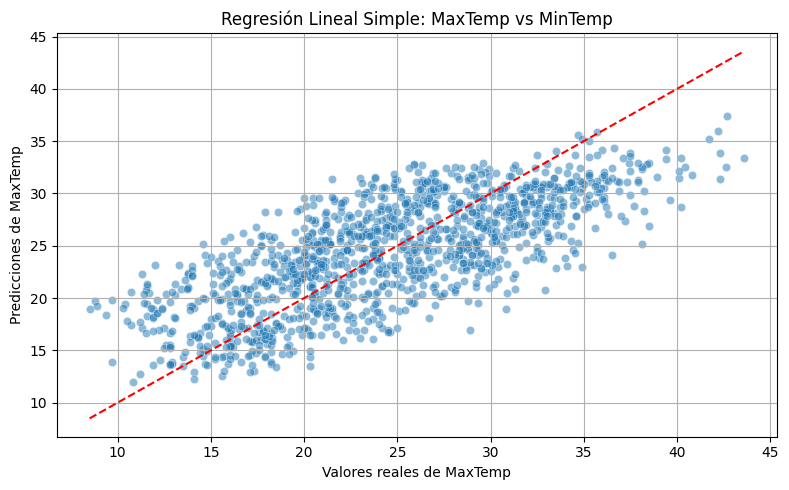

In [74]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # línea ideal
plt.xlabel('Valores reales de MaxTemp')
plt.ylabel('Predicciones de MaxTemp')
plt.title('Regresión Lineal Simple: MaxTemp vs MinTemp')
plt.grid(True)
plt.tight_layout()
plt.show()

#Regresion Lineal Multiple


In [23]:
variables = ['MinTemp', 'Humidity3pm', 'Pressure9am', 'Temp3pm', 'WindSpeed3pm', 'MaxTemp']
df_multiple = df[variables].dropna()

In [24]:
# Separar variables dependientes e independientes
X = df_multiple.drop('MaxTemp', axis=1)
y = df_multiple['MaxTemp']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [27]:
print("📊 Regresión Lineal Múltiple:")
print(f"R² Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

📊 Regresión Lineal Múltiple:
R² Score: 0.9829
RMSE: 0.8972


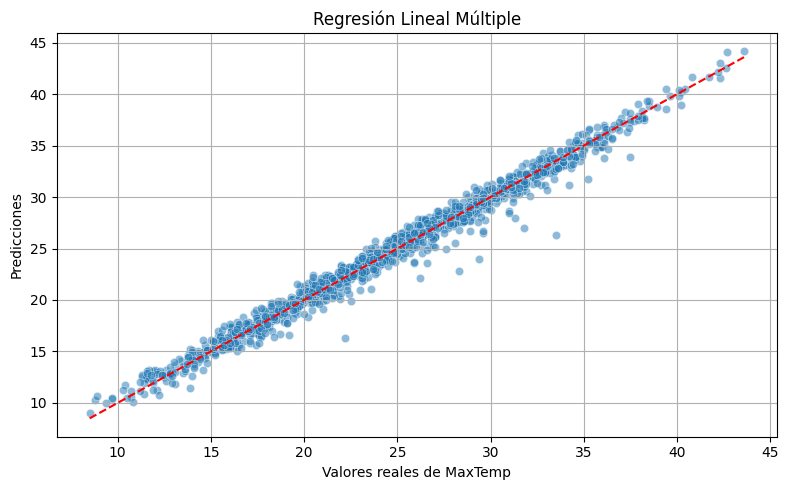

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores reales de MaxTemp')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal Múltiple')
plt.grid(True)
plt.tight_layout()
plt.show()

#Random Forest


In [17]:
df= df.dropna()
df['MaxTempClass'] = pd.cut(
    df['MaxTemp'],
    bins=[-np.inf, 21, 28, np.inf],
    labels=['Baja', 'Media', 'Alta'],
    right=True
)
X = df.drop(['Date', 'MaxTemp', 'MaxTempClass'], axis=1)
y = df['MaxTempClass']

<ipython-input-17-568cc12fdaf0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MaxTempClass'] = pd.cut(


In [18]:
numerical_features = df.select_dtypes(include=['number']).columns
X = df[numerical_features].drop(['MaxTemp'], axis=1)
y = df['MaxTempClass']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
clf = RandomForestClassifier(n_estimators=500, max_features=int(X.shape[1]/3), min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(max_features=6, min_samples_leaf=5, n_estimators=500,
                       random_state=42)

In [21]:
estimator = clf.estimators_[0]

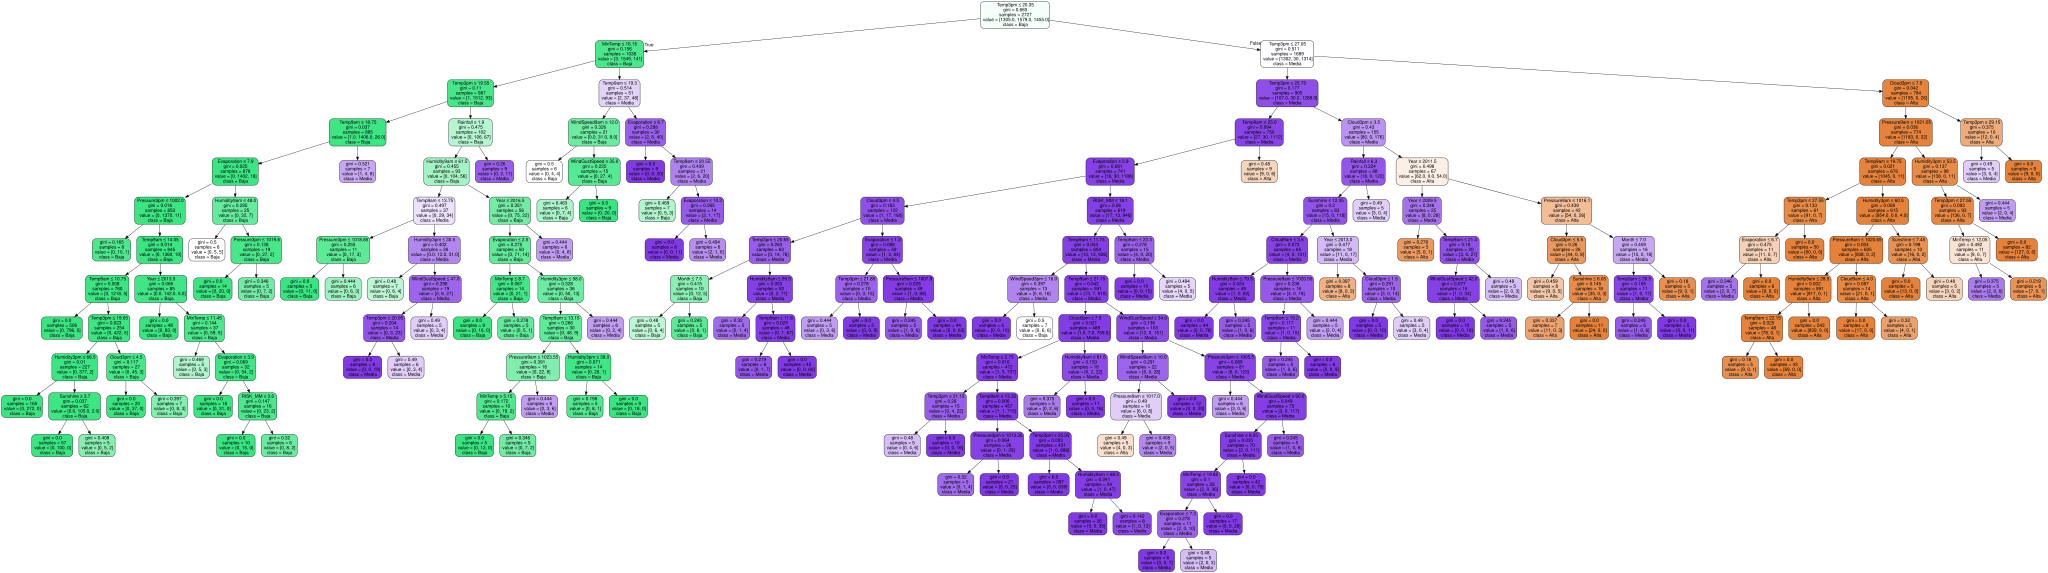

In [22]:
dot_data = export_graphviz(estimator,
                           out_file=None,
                           feature_names=X.columns,
                           class_names=clf.classes_,
                           filled=True, rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("random_forest_classifier_tree", format='png', cleanup=False)
graph

#Support vector machine


In [40]:
df_class = df.copy()
df_class['MaxTempClass'] = pd.cut(
    df_class['MaxTemp'],
    bins=[-np.inf, 21, 28, np.inf],
    labels=['Baja', 'Media', 'Alta'],
    right=True
)

In [41]:
x = df_class.drop(['MaxTemp', 'MaxTempClass'], axis=1)
y = df_class['MaxTempClass']

In [43]:
df_class = pd.get_dummies(df, drop_first=True)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [46]:
model = SVC(kernel='rbf')
model.fit(X_train_scaled, y_train)

SVC()

In [47]:
y_pred = model.predict(X_test_scaled)


In [48]:
accuracy = accuracy_score(y_test, y_pred)
print("Precisión:", accuracy_score(y_test, y_pred))
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Precisión: 0.9193548387096774
Reporte de clasificación:
              precision    recall  f1-score   support

        Alta       0.97      0.91      0.94       407
        Baja       0.94      0.94      0.94       423
       Media       0.86      0.91      0.88       410

    accuracy                           0.92      1240
   macro avg       0.92      0.92      0.92      1240
weighted avg       0.92      0.92      0.92      1240



#Naive Bayes


In [49]:
df_class2 = df.copy()
df_class2['MaxTempClass'] = pd.cut(
    df_class2['MaxTemp'],
    bins=[-np.inf, 21, 28, np.inf],
    labels=['Baja', 'Media', 'Alta'],
    right=True
)

In [52]:
X_class = df_class2.drop(['MaxTemp', 'MaxTempClass', 'Date'], axis=1)
y_class = df_class2['MaxTempClass']

In [53]:
X_class = pd.get_dummies(X_class, drop_first=True)

In [54]:
print(X_class.dtypes)

MinTemp                  float64
Rainfall                 float64
Evaporation              float64
Sunshine                 float64
WindGustSpeed            float64
                          ...   
WindDir3pm_WNW_True         bool
WindDir3pm_WSW_True         bool
WindDir3pm_nan_True         bool
RainToday_Yes_True          bool
RainTomorrow_Yes_True       bool
Length: 70, dtype: object


In [55]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

In [56]:
model = GaussianNB()
model.fit(X_train_c, y_train_c)

GaussianNB()

In [57]:
y_pred = model.predict(X_test_c)

In [62]:
print("\n Naive Bayes (Clasificación de MaxTemp):")
print(classification_report(y_test_c, y_pred))
print(f" Accuracy Naive Bayes: {accuracy_score(y_test_c, y_pred):.2%}")



 Naive Bayes (Clasificación de MaxTemp):
              precision    recall  f1-score   support

        Alta       0.84      0.78      0.81       602
        Baja       0.80      0.82      0.81       627
       Media       0.64      0.68      0.66       631

    accuracy                           0.76      1860
   macro avg       0.76      0.76      0.76      1860
weighted avg       0.76      0.76      0.76      1860

 Accuracy Naive Bayes: 75.81%


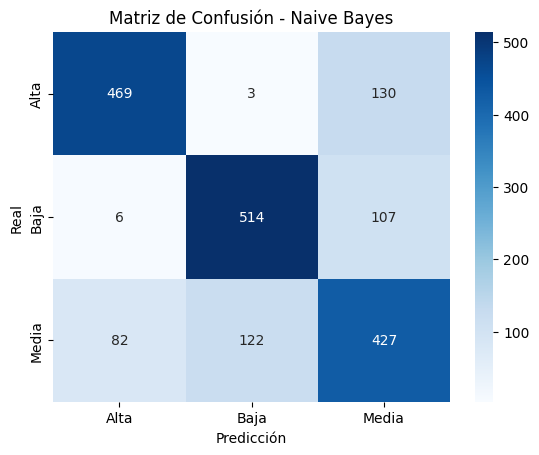

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
conf_matrix = confusion_matrix(y_test_c, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Matriz de Confusión - Naive Bayes")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()